# 03 — Differential Evolution Optimizer
**APV-AD Project | Step 3 of 7**

This notebook runs the DE optimizer for all four sites and saves results.

**Structure:**
1. Load hourly data + import simulation functions
2. Run DE for each site (site-by-site with auto-save)
3. Show convergence curve for each site
4. Save `optimal_params.json` — used by all subsequent notebooks

**Run time:** 15–45 minutes total (all 4 sites)  
**Output:** `outputs/csv/optimal_params.json`, `outputs/figures/fig_convergence.png`

> If the notebook crashes mid-run, completed sites are already saved.  
> Re-run from Cell 4 — it skips sites already in `optimal_params.json`.


In [1]:
import sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import differential_evolution, minimize

warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path.cwd()))
from config_00 import SITES, PARAMS, DE_SETTINGS, CSV_DIR, FIG_DIR, FIG_STYLE
from simulation_functions import eLER_objective

# Load hourly climate data
TMY = {}
for site in SITES:
    p = CSV_DIR / f"hourly_{site}.csv"
    if not p.exists():
        raise FileNotFoundError(f"Run 01_load_data.ipynb first — missing {p}")
    TMY[site] = pd.read_csv(p, index_col=0, parse_dates=True)

RESULTS_PATH = CSV_DIR / "optimal_params.json"

print("Ready. Sites:", list(SITES.keys()))
print(f"DE settings: NP={DE_SETTINGS['population_size']}, "
      f"G={DE_SETTINGS['max_generations']}, "
      f"Cr={DE_SETTINGS['crossover_Cr']}, "
      f"F={DE_SETTINGS['mutation_F']}")
print(f"V_dig bounds: {DE_SETTINGS['bounds'][3]} m³")
print(f"OLR constraint: [{DE_SETTINGS['OLR_min']}, {DE_SETTINGS['OLR_max']}] kg VS/m³/d")


Ready. Sites: ['Konya', 'Almeria', 'Ouagadougou', 'Freiburg']
DE settings: NP=90, G=50, Cr=0.7, F=(0.5, 1.0)
V_dig bounds: (2.0, 50.0) m³
OLR constraint: [1.5, 5.0] kg VS/m³/d


In [2]:
class ConvergenceTracker:
    """
    Callback for scipy differential_evolution.
    Records best eLER at each generation for the convergence plot.
    Also prints a progress line every 5 generations.
    """
    def __init__(self, site: str, n_gen: int):
        self.site    = site
        self.n_gen   = n_gen
        self.history = []
        self.gen     = 0
        self.t_start = time.time()

    def __call__(self, xk, convergence):
        """Called by scipy after each generation."""
        self.gen += 1
        # xk is the best solution so far — evaluate to get eLER
        val = eLER_objective(xk, TMY[self.site], self.site)
        # scipy minimizes, so val = -eLER; convert back
        eLER_val = -val if val < 0 else val
        self.history.append(eLER_val)

        if self.gen % 5 == 0 or self.gen == self.n_gen:
            elapsed = time.time() - self.t_start
            eta     = elapsed / self.gen * (self.n_gen - self.gen)
            print(f"  Gen {self.gen:3d}/{self.n_gen}  "
                  f"best eLER = {eLER_val:.4f}  "
                  f"elapsed = {elapsed:.0f}s  "
                  f"ETA = {eta:.0f}s")
        return False   # False = do not stop early

print("ConvergenceTracker defined. ✓")


ConvergenceTracker defined. ✓


In [3]:
# =============================================================================
# Run DE optimization — site by site with auto-save
# Skips sites already completed in optimal_params.json
# =============================================================================

# Load existing results if any
if RESULTS_PATH.exists():
    all_results = json.loads(RESULTS_PATH.read_text())
    print(f"Loaded existing results: {list(all_results.keys())}")
else:
    all_results = {}

CONVERGENCE = {}   # site → list of best eLER per generation

for site in SITES:

    if site in all_results:
        print(f"\n[{site}] Already optimized — skipping. "
              f"(eLER = {all_results[site]['eLER_defA']:.4f})")
        continue

    print(f"\n{'='*60}")
    print(f"  Optimizing {site} ({SITES[site]['koppen']})")
    print(f"{'='*60}")
    t0 = time.time()

    tracker = ConvergenceTracker(site, DE_SETTINGS["max_generations"])

    # scipy differential_evolution MINIMIZES — negate eLER
    def neg_eLER(x):
        val = eLER_objective(x, TMY[site], site)
        return -val   # negate for minimization

    result = differential_evolution(
        neg_eLER,
        bounds     = DE_SETTINGS["bounds"],
        maxiter    = DE_SETTINGS["max_generations"],
        popsize    = DE_SETTINGS["population_size"] // len(DE_SETTINGS["bounds"]),
        mutation   = DE_SETTINGS["mutation_F"],
        recombination = DE_SETTINGS["crossover_Cr"],
        seed       = DE_SETTINGS["seed"],
        callback   = tracker,
        tol        = 1e-6,
        polish     = False,    # we do our own polishing below
        workers    = 1,        # single-threaded for reproducibility
    )

    # ── L-BFGS-B local polishing ─────────────────────────────────────────────
    print(f"  DE converged. Polishing with L-BFGS-B...")
    bounds_scipy = [(lo, hi) for lo, hi in DE_SETTINGS["bounds"]]
    polish_result = minimize(
        neg_eLER,
        x0     = result.x,
        method = "L-BFGS-B",
        bounds = bounds_scipy,
        options= {"maxiter": 500, "ftol": 1e-10},
    )
    x_opt = polish_result.x if polish_result.fun < result.fun else result.x

    # ── Get full results dict ─────────────────────────────────────────────────
    full = eLER_objective(x_opt, TMY[site], site, return_full=True)

    if full is None:
        print(f"  WARNING: optimal solution is infeasible for {site}!")
        print(f"  OLR may be out of bounds — widening and retrying...")
        # Retry with relaxed OLR for diagnostics
        DE_SETTINGS["OLR_min"] = 0.0
        DE_SETTINGS["OLR_max"] = 99.0
        full = eLER_objective(x_opt, TMY[site], site, return_full=True)
        DE_SETTINGS["OLR_min"] = 1.5
        DE_SETTINGS["OLR_max"] = 5.0
        full["OLR_INFEASIBLE"] = True

    elapsed = time.time() - t0
    full["site"]         = site
    full["runtime_sec"]  = round(elapsed, 1)
    CONVERGENCE[site]    = tracker.history

    # ── Auto-save after each site ─────────────────────────────────────────────
    all_results[site] = full
    RESULTS_PATH.write_text(json.dumps(all_results, indent=2))

    # ── Print site summary ────────────────────────────────────────────────────
    print(f"\n  ── {site} RESULT ──────────────────────────────")
    print(f"  eLER (Def A)   : {full['eLER_defA']:.4f}")
    print(f"  LER_crop       : {full['LER_crop']:.3f}")
    print(f"  LER_PV (Def A) : {full['LER_PV_defA']:.3f}")
    print(f"  LER_biogas     : {full['LER_biogas']:.3f}")
    print(f"  LER_2C         : {full['LER_2C']:.3f}")
    print(f"  β*={full['beta_deg']:.1f}°  d_row*={full['d_row_m']:.2f}m  "
          f"H_m*={full['H_m_m']:.2f}m")
    print(f"  V_dig*={full['V_dig_m3']:.1f}m³  HRT*={full['HRT_days']:.1f}d  "
          f"OLR={full['OLR_kgVS_m3d']:.3f}")
    print(f"  PV={full['PV_total_MWh_ha']:.0f} MWh/ha  "
          f"Biogas={full['biogas_total_MWh_ha']:.2f} MWh/ha  "
          f"ESR={full['ESR']:.1f}")
    print(f"  Runtime: {elapsed:.0f}s")

print(f"\n{'='*60}")
print(f"  All sites optimized.")
print(f"  Results saved → {RESULTS_PATH}")
print(f"{'='*60}")



  Optimizing Konya (BSk)
  Gen   5/50  best eLER = 1.4097  elapsed = 12s  ETA = 106s
  Gen  10/50  best eLER = 1.4642  elapsed = 24s  ETA = 98s
  Gen  15/50  best eLER = 1.4756  elapsed = 35s  ETA = 81s
  Gen  20/50  best eLER = 1.4915  elapsed = 46s  ETA = 68s
  Gen  25/50  best eLER = 1.4942  elapsed = 56s  ETA = 56s
  Gen  30/50  best eLER = 1.4964  elapsed = 67s  ETA = 45s
  Gen  35/50  best eLER = 1.4978  elapsed = 77s  ETA = 33s
  Gen  40/50  best eLER = 1.4979  elapsed = 88s  ETA = 22s
  Gen  45/50  best eLER = 1.4983  elapsed = 98s  ETA = 11s
  Gen  50/50  best eLER = 1.4985  elapsed = 108s  ETA = 0s
  DE converged. Polishing with L-BFGS-B...

  ── Konya RESULT ──────────────────────────────
  eLER (Def A)   : 1.4980
  LER_crop       : 0.368
  LER_PV (Def A) : 0.513
  LER_biogas     : 0.618
  LER_2C         : 0.881
  β*=12.5°  d_row*=4.16m  H_m*=2.00m
  V_dig*=4.5m³  HRT*=37.6d  OLR=1.533
  PV=917 MWh/ha  Biogas=3.70 MWh/ha  ESR=479.2
  Runtime: 118s

  Optimizing Almeria (BSh

In [4]:
# =============================================================================
# Summary table — compare all 4 sites
# =============================================================================

if not RESULTS_PATH.exists():
    print("No results yet — run Cell 4 first.")
else:
    res = json.loads(RESULTS_PATH.read_text())

    metrics = [
        ("Tilt β* (°)",          "beta_deg",         "{:.1f}"),
        ("Row spacing d_row* (m)","d_row_m",          "{:.2f}"),
        ("Module height H_m* (m)","H_m_m",            "{:.2f}"),
        ("Digester V_dig* (m³)", "V_dig_m3",         "{:.1f}"),
        ("HRT* (days)",          "HRT_days",         "{:.1f}"),
        ("f_PV_heat*",           "f_PV_heat",        "{:.3f}"),
        ("GCR (%)",              "GCR_pct",          "{:.1f}"),
        ("OLR (kg VS/m³/d)",     "OLR_kgVS_m3d",    "{:.3f}"),
        ("PV total (MWh/ha)",    "PV_total_MWh_ha",  "{:.0f}"),
        ("Biogas (MWh/ha)",      "biogas_total_MWh_ha","{:.2f}"),
        ("Heat demand (MWh/ha)", "heat_demand_MWh_ha","{:.2f}"),
        ("ESR",                  "ESR",              "{:.1f}"),
        ("BMP avg (NmL/gVS)",    "BMP_avg_NmL_gVS",  "{:.1f}"),
        ("LER_crop",             "LER_crop",         "{:.3f}"),
        ("LER_PV (Def A)",       "LER_PV_defA",      "{:.3f}"),
        ("LER_PV (Def B = GCR)", "LER_PV_defB",      "{:.3f}"),
        ("LER_biogas",           "LER_biogas",       "{:.3f}"),
        ("eLER (Def A)",         "eLER_defA",        "{:.3f}"),
        ("LER_2C",               "LER_2C",           "{:.3f}"),
        ("W_saved season (mm)",  "W_saved_mm_season","{:.1f}"),
        ("ET₀ season (mm)",      "ET0_season_mm",    "{:.1f}"),
        ("LER_water season (%)", "LER_water_season_pct","{:.2f}"),
    ]

    sites = list(res.keys())
    print("\n" + "="*72)
    print(f"  OPTIMAL DESIGN & PERFORMANCE — all 4 sites (Scenario S0)")
    print("="*72)
    print(f"  {'Metric':30s}", end="")
    for s in sites:
        print(f"  {s:>12}", end="")
    print()
    print("  " + "-"*68)

    for label, key, fmt in metrics:
        print(f"  {label:30s}", end="")
        for s in sites:
            val = res[s].get(key, float("nan"))
            try:
                print(f"  {fmt.format(val):>12}", end="")
            except:
                print(f"  {'N/A':>12}", end="")
        print()

    print("="*72)
    print(f"  Benchmark LER_2C (Riaz et al. 2022) = 1.94")
    print("="*72)



  OPTIMAL DESIGN & PERFORMANCE — all 4 sites (Scenario S0)
  Metric                                 Konya       Almeria   Ouagadougou      Freiburg
  --------------------------------------------------------------------
  Tilt β* (°)                             12.5          11.0          10.4          10.3
  Row spacing d_row* (m)                  4.16          4.17          4.17          4.16
  Module height H_m* (m)                  2.00          2.00          2.00          2.00
  Digester V_dig* (m³)                     4.5           3.4           2.3           2.4
  HRT* (days)                             37.6          21.3          29.1          27.6
  f_PV_heat*                             0.050         0.051         0.050         0.050
  GCR (%)                                 53.4          53.7          53.8          53.9
  OLR (kg VS/m³/d)                       1.533         1.999         3.092         2.402
  PV total (MWh/ha)                        917          1050        

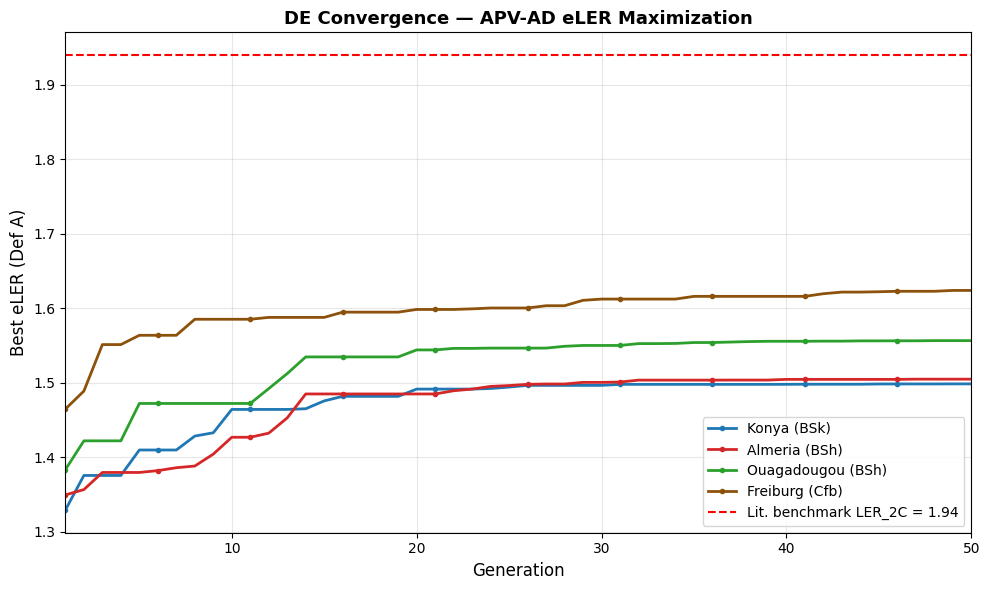

Convergence figure saved → C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig_convergence.png


In [5]:
# =============================================================================
# Convergence curves — one line per site
# =============================================================================

if not CONVERGENCE:
    print("No convergence data — run Cell 4 first.")
else:
    fig, ax = plt.subplots(figsize=FIG_STYLE["figsize_single"])

    for site, history in CONVERGENCE.items():
        color = FIG_STYLE["site_colors"][site]
        ax.plot(range(1, len(history)+1), history,
                color=color, linewidth=2, label=f"{site} ({SITES[site]['koppen']})",
                marker="o", markersize=3, markevery=5)

    ax.axhline(1.94, color="red", linewidth=1.5, linestyle="--",
               label="Lit. benchmark LER_2C = 1.94")
    ax.set_xlabel("Generation", fontsize=12)
    ax.set_ylabel("Best eLER (Def A)", fontsize=12)
    ax.set_title("DE Convergence — APV-AD eLER Maximization", fontsize=13,
                 fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, DE_SETTINGS["max_generations"])

    plt.tight_layout()
    out = FIG_DIR / "fig_convergence.png"
    plt.savefig(out, dpi=FIG_STYLE["dpi"], bbox_inches="tight")
    plt.show()
    print(f"Convergence figure saved → {out}")


In [6]:
print("\n" + "="*55)
print("  03_optimizer — COMPLETE")
print("="*55)
print(f"  ✓ {RESULTS_PATH}")
print(f"  ✓ {FIG_DIR / 'fig_convergence.png'}")
print("\nNext step → open 04_metrics.ipynb")
print("="*55)



  03_optimizer — COMPLETE
  ✓ C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\csv\optimal_params.json
  ✓ C:\Users\AMIDOU MAIGA\OneDrive - Institut 2IE\Desktop\APV + AD\APV_AD_Project\outputs\figures\fig_convergence.png

Next step → open 04_metrics.ipynb
